# LCM Training Monitor

This notebook provides tools to monitor the training progress of the LCM model and perform inference.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

## Training Metrics Visualization

In [2]:
def load_metrics(csv_path: str) -> pd.DataFrame:
    """Load training metrics from CSV file."""
    metrics_df = pd.read_csv(csv_path)
    metrics_df["lr-AdamW"] = metrics_df["lr-AdamW"].ffill()

    metrics_df = metrics_df[metrics_df["train_loss"].notna() + metrics_df["val_loss"].notna()]
    metrics_df = metrics_df.groupby("epoch").mean()

    metrics_df = metrics_df.reset_index()

    return metrics_df

In [3]:
def plot_metrics(metrics_df: pd.DataFrame) -> None:
    """Plot training metrics."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(metrics_df["epoch"], metrics_df["train_loss"], label="Train Loss")
    ax1.plot(metrics_df["epoch"], metrics_df["val_loss"], label="Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_ylim(0.00, 0.8)
    ax1.set_title("Training and Validation Loss")
    ax1.legend()
    ax1.grid(True)

    # Plot learning rate
    ax2.plot(metrics_df["epoch"], metrics_df["lr-AdamW"], label="Learning Rate")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning Rate")
    ax2.set_title("Learning Rate Schedule")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

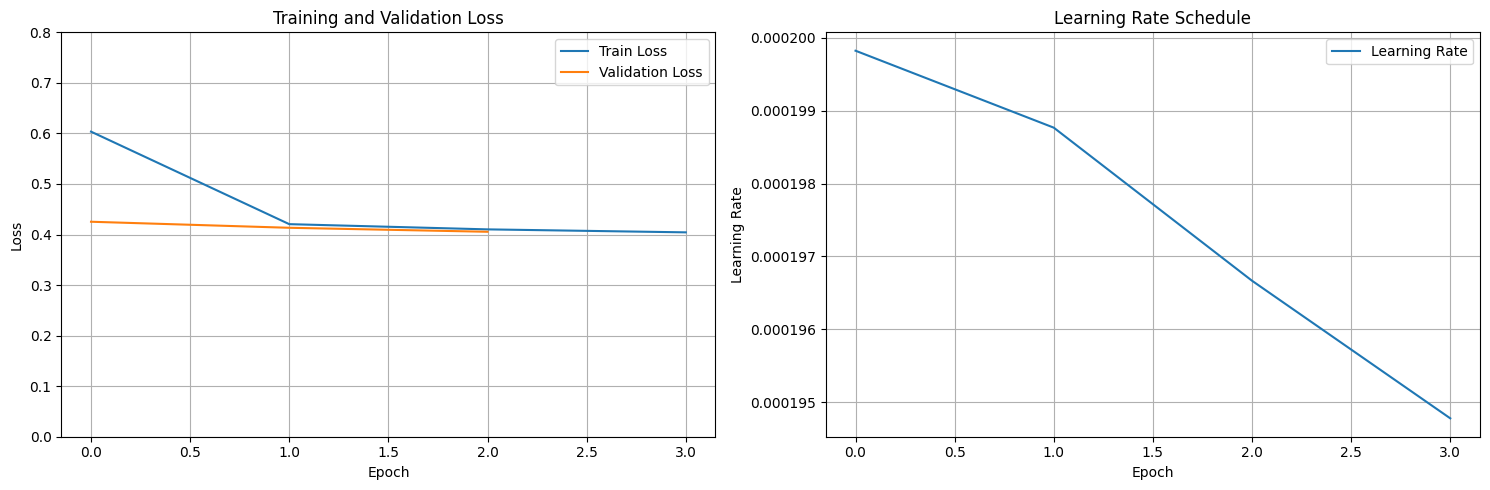

In [5]:
metrics_path = "/home/yannhallouard/PycharmProjects/large_concept_model/lightning_logs/version_14/metrics.csv"
metrics_df = load_metrics(metrics_path)

plot_metrics(metrics_df)

## Model Inference

This section allows you to load a trained model and perform inference on new text.

In [6]:
from lcm_explo.adapters.embedding_repository.file_system import FileSystemEmbeddingRepository
from lcm_explo.domain.models.base_lcm import BaseLCM, BaseLCMConfig
from lcm_explo.domain.usecases.train import BaseLCMTrainingModule

In [7]:
embeddings_repo = FileSystemEmbeddingRepository(base_path="data")
example_doc = embeddings_repo.load_document_embeddings("logicot_entry_0")
example_doc.embeddings.shape

torch.Size([43, 1024])

In [8]:
def generate_next_concepts(model: BaseLCM, input_embeddings: torch.Tensor, num_steps: int = 10) -> torch.Tensor:
    """Generate next concepts using the model."""
    device = next(model.parameters()).device

    # Move input to same device as model
    input_embeddings = input_embeddings.to(device)

    # Generate next concepts
    with torch.no_grad():
        current_sequence = input_embeddings
        generated_sequence = [current_sequence]

        for _ in range(num_steps):
            # Get next concept prediction
            padding_mask = torch.ones(current_sequence.shape[0]).to(device)
            next_concept = model(current_sequence, padding_mask)

            # Update sequence
            current_sequence = torch.cat([current_sequence[:, 1:], next_concept[:, -1:]], dim=1)
            generated_sequence.append(next_concept[:, -1:])

    return torch.cat(generated_sequence, dim=1)

In [9]:
checkpoint_path = "data/checkpoints/lcm-epoch=41-val_loss=0.3576.ckpt"
config = BaseLCMConfig()
model = BaseLCMTrainingModule.load_from_checkpoint(
    checkpoint_path,
)

In [21]:
# Load some example embeddings
embeddings_repo = FileSystemEmbeddingRepository(base_path="data")
example_doc = embeddings_repo.load_document_embeddings("logicot_entry_0")

# Generate next concepts
input_embeddings = example_doc.embeddings[-32:].unsqueeze(0)  # Add batch dimension
generated_sequence = generate_next_concepts(model, input_embeddings, num_steps=10)

print(f"Generated sequence shape: {generated_sequence.shape}")

Generated sequence shape: torch.Size([1, 42, 1024])


In [22]:
input_embeddings.shape

torch.Size([1, 32, 1024])

In [23]:
from transformers import NllbTokenizer

from lcm_explo.m2m_100 import M2M100DecoderModel

decoder = M2M100DecoderModel.from_pretrained("cointegrated/SONAR_200_text_decoder_hf").to("cuda")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

In [44]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

all_text = []

for i in tqdm(range(generated_sequence.shape[1])):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=generated_sequence[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    all_text.append(text_out[0])
print(all_text)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [00:05<00:00,  6.05it/s]

['sent8: a motion is a kind of event / action .', 'sent9: including means containing .', 'sent10: movement is when moves an object / something in a direction .', 'sent11: planets in the solar system orbit around the sun .', 'sent12: approximately means about .', 'sent13: planets orbit around stars .', 'sent14: how something appears is how that something looks .', 'sent15: throughout means over .', 'sent16: movement / movement means moving / to move .', 'sent17: a constellation contains stars .', 'sent18: years (y) is a metric unit used to measure time generally used for', 'sent19: similar means in common .', 'sent20: the solar system is a kind of system .', 'sent21: moving in a circle means moving in a circular movement .', 'sent22: a celestial body traveling around another celestial body means that that', 'sent23: rotation is the circular movement of an object around a center / axis .', 'sent24: an orbit is a kind of regular path .', 'sent25: the earth rotating around the sun causes s

In [25]:
all_text[-11]

'int2: the earth rotating around the sun causes leo to appear in different areas in the sky'

In [15]:
from transformers import NllbTokenizer
from wtpsplit import SaT

from lcm_explo.domain.usecases.encode import encode_text_sonar
from lcm_explo.m2m_100 import M2M100EncoderModel

sonar_encoder = M2M100EncoderModel.from_pretrained("cointegrated/SONAR_200_text_encoder_hf").to("cuda")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

splitter = SaT("sat-3l")

In [31]:
my_text = """
Its position appears to shift relative to the horizon.
Based on the context, we can infer the hypothesis: the earth rotating on its axis causes stars to move relative to the horizon during the night
Reasoning chain: sent11 & sent3 & sent8 -> int1: apparent motion of stars is when stars appear to move relative to earth's position; int1 & sent6 -> int2: the earth rotating on its axis causes apparent motion of stars; int2 & sent23 -> hypothesis;
Proof: [BECAUSE] a star is a kind of celestial object / celestial body [AND] apparent motion is when an object appears to move relative to another object 's position [AND] earth is a kind of celestial object [INFER] int1: apparent motion of stars is when stars appear to move relative to earth's position [BECAUSE] int1 [AND] the earth rotating on its axis causes stars to appear to move across the sky at night [INFER] int2: the earth rotating on its axis causes apparent motion of stars [BECAUSE] int2 [AND] stars appear to move relative to the horizon during the night [INFER] int3: the earth rotating on its axis causes stars to move relative to the horizon during the night
""" 

embeddings = encode_text_sonar(
    my_text, device="cuda", sonar_tokenizer=sonar_tokenizer, sonar_model=sonar_encoder, splitter=splitter
)

input_embeddings = embeddings.unsqueeze(0)
my_generated_sequence = generate_next_concepts(model, input_embeddings, num_steps=10)

print(f"Generated sequence shape: {my_generated_sequence.shape}")

NameError: name 'model' is not defined

In [32]:
from transformers.modeling_outputs import BaseModelOutput

def split_long_text(tokenizer, splitter, text: str, max_length: int = 1024) -> list[str]:
    splits = splitter.split(text)
    splits = [split for split in splits if split.replace(" ", "") != "" and len(split) > 10]
    return splits


refined_text = my_text.replace("sent", ". sent")


embeddings = []
with torch.no_grad():
    chunks = split_long_text(sonar_tokenizer, splitter, refined_text)
    for chunk in chunks:
        inputs = sonar_tokenizer(chunk, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to("cuda") for k, v in inputs.items()}
        outputs = sonar_encoder(**inputs)
        embeddings.append(outputs.last_hidden_state.mean(dim=1))

out = torch.vstack(embeddings)

generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=out.unsqueeze(1)),
    num_beams=5,
    forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
)
text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
text_out

['Its position seems to shift relative to the horizon.',
 'Based on the context, we can infer the hypothesis: that earth rotating on',
 'Reasoning chain:',
 'sent11 & .',
 'int1: apparent movement of stars is when stars appear to move relative to earth position;',
 'int2: the earth rotating on its axis causes apparent movement of stars;',
 'sent23 -> hypothesis;',
 'Proof: [Why]',
 'a star is a kind of celestial object / celestial body [AND]',
 'apparent motion is when an object appears to move relative to the position of another object [AND',
 'earth is a kind of celestial object [INFER]',
 "int1: apparent movement of stars is when stars appear to move relative to earth's position",
 'int1 [AND]',
 "the earth's rotation on its axis causes stars to appear to move across the night",
 'int2: Earth rotating on its axis causes apparent movement of stars [WHY]',
 'int2 [AND]',
 'Stars seem to move relative to the horizon during the night [INFER].',
 'int3: the earth rotating on its axis cau

In [33]:
chunks

['Its position appears to shift relative to the horizon.',
 'Based on the context, we can infer the hypothesis: the earth rotating on its axis causes stars to move relative to the horizon during the night',
 'Reasoning chain: ',
 'sent11 & . ',
 "int1: apparent motion of stars is when stars appear to move relative to earth's position; ",
 'int2: the earth rotating on its axis causes apparent motion of stars; ',
 'sent23 -> hypothesis;',
 'Proof: [BECAUSE] ',
 'a star is a kind of celestial object / celestial body [AND] ',
 "apparent motion is when an object appears to move relative to another object 's position [AND] ",
 'earth is a kind of celestial object [INFER] ',
 "int1: apparent motion of stars is when stars appear to move relative to earth's position [BECAUSE] ",
 'int1 [AND] ',
 'the earth rotating on its axis causes stars to appear to move across the sky at night [INFER] ',
 'int2: the earth rotating on its axis causes apparent motion of stars [BECAUSE] ',
 'int2 [AND] ',
 'st

In [30]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

my_all_text = []

for i in tqdm(range(my_generated_sequence.shape[1])):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=my_generated_sequence[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    my_all_text.append(text_out[0])
print(my_all_text)

NameError: name 'my_generated_sequence' is not defined